# Spatially Varying Coefficients — Real OPV Morphology

This notebook answers one question: **how do the material coefficients and field solutions
change spatially when you use a real BHJ morphology?**

No PINN training here. We:
1. Load a real morphology from `chem_morph_data.npy`
2. Compute spatially varying Gx, mu_n, mu_p at every point
3. Build analytical approximations of the fields to show how they respond
4. Visualise everything side by side so you can see the spatial coupling

Set `DATA_DIR` and `MORPH_IDX` below.

## Cell 1 — Setup

In [1]:
!pip install scipy


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter
import warnings
warnings.filterwarnings('ignore')

# ── SET THESE ────────────────────────────────────────────────────────────────
DATA_DIR  = 'C:/Users/shant/OneDrive/Desktop/opv_pinn/ff_data'        # path to folder containing chem_morph_data.npy
MORPH_IDX = 0          # which morphology to analyse (0 to 72750)
GRID_SIZE = 128        # resolution for visualisation (128 = full resolution)
# ─────────────────────────────────────────────────────────────────────────────

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})
print('Setup complete.')

Setup complete.


## Cell 2 — Physical parameters

In [3]:
# ── Physical constants ────────────────────────────────────────────────────────
q    = 1.602e-19   # C
kb   = 1.381e-23   # J/K
eps0 = 8.854e-12   # F/m
T    = 300.0       # K

# ── Config.txt values ────────────────────────────────────────────────────────
mu_n    = 2e-7     # m²/Vs
mu_p    = 1.5e-7   # m²/Vs
mu_x    = 3.9e-9   # m²/Vs
eps_D   = 3.0
eps_A   = 3.9
E_g     = 1.1      # eV
tau_x   = 1e-6     # s
Gx_phys = 1e28     # m⁻³s⁻¹
Height  = 100e-9   # m
muRatio = 0.01     # minority carrier reduction

# ── Derived ──────────────────────────────────────────────────────────────────
VT      = kb * T / q
Dn      = mu_n * VT
Dp      = mu_p * VT
Dx      = mu_x * VT
kx      = 1.0 / tau_x
eps_avg = (eps_D + eps_A) / 2
eps_si  = eps_avg * eps0
k_diss  = 1e6
k_rec   = q * (mu_n + mu_p) / eps_si
V_bi    = E_g - 2*VT

# ── Non-dimensionalisation ────────────────────────────────────────────────────
L0   = Height
V0   = E_g
n0   = 1e22       # balanced: Gx_nd = kx_nd
tau0 = L0**2 / Dn

Gx_nd    = Gx_phys * tau0 / n0
kx_nd    = kx * tau0
kdiss_nd = k_diss * tau0
krec_nd  = k_rec * n0 * tau0
V_bi_nd  = V_bi / V0
debye    = q * n0 * L0**2 / (eps_si * V0)
J_scale  = n0 * Dn * q / L0   # A/m²

print('Dimensionless parameters:')
print(f'  Gx_nd       = {Gx_nd:.4f}')
print(f'  kx_nd       = {kx_nd:.4f}')
print(f'  Gx_nd/kx_nd = {Gx_nd/kx_nd:.4f}  (should be ~1)')
print(f'  kdiss_nd    = {kdiss_nd:.4f}')
print(f'  krec_nd     = {krec_nd:.4f}')
print(f'  V_bi_nd     = {V_bi_nd:.4f}')
print(f'  debye_ratio = {debye:.4f}')
print(f'  J_scale     = {J_scale*0.1:.4f} mA/cm² per J_nd')

Dimensionless parameters:
  Gx_nd       = 1.9334
  kx_nd       = 1.9334
  Gx_nd/kx_nd = 1.0000  (should be ~1)
  kdiss_nd    = 1.9334
  krec_nd     = 35.4887
  V_bi_nd     = 0.9530
  debye_ratio = 0.4768
  J_scale     = 8.2860 mA/cm² per J_nd


## Cell 3 — Load morphology

In [4]:
import os

path = os.path.join(DATA_DIR, 'chem_morph_data.npy')
print(f'Loading {path} ...')
chem_data = np.load(path, allow_pickle=True)
n_total   = len(chem_data)
print(f'Dataset: {n_total} samples')

row          = chem_data[MORPH_IDX]
morph_grid   = np.array(row[0], dtype=np.float32)   # (128, 128)
mat_params   = np.array(row[1], dtype=np.float32)   # (5,)
gt_jsc       = float(row[2])                         # mA/cm²

print(f'\nMorphology #{MORPH_IDX}:')
print(f'  Grid shape   : {morph_grid.shape}')
print(f'  Phase range  : [{morph_grid.min():.3f}, {morph_grid.max():.3f}]')
print(f'  Donor frac   : {(morph_grid > 0.5).mean():.3f}')
print(f'  GT Jsc       : {gt_jsc:.4f} mA/cm²')
print(f'  Mat. params  : {mat_params}')
print(f'    p0=mu_n={mat_params[0]:.1e}  p1=mu_p={mat_params[1]:.1e}')
print(f'    p2=mu_x={mat_params[2]:.1e}  p3=kdiss_factor={mat_params[3]:.1f}')
print(f'    p4=tau_x={mat_params[4]:.1e}')

Loading C:/Users/shant/OneDrive/Desktop/opv_pinn/ff_data\chem_morph_data.npy ...
Dataset: 72751 samples

Morphology #0:
  Grid shape   : (128, 128)
  Phase range  : [0.020, 0.982]
  Donor frac   : 0.339
  GT Jsc       : 2.6280 mA/cm²
  Mat. params  : [1.e-05 1.e-05 1.e-05 1.e+00 1.e-06]
    p0=mu_n=1.0e-05  p1=mu_p=1.0e-05
    p2=mu_x=1.0e-05  p3=kdiss_factor=1.0
    p4=tau_x=1.0e-06


## Cell 4 — Build spatially varying coefficient maps

This is the core of what the PINN uses internally.
At every point (x, y) the material is either donor or acceptor,
and each coefficient takes a different value accordingly.

In [5]:
# ── Build interpolator on [0,1]² ─────────────────────────────────────────────
H, W  = morph_grid.shape
xgrid = np.linspace(0, 1, H)
ygrid = np.linspace(0, 1, W)
interp = RegularGridInterpolator(
    (xgrid, ygrid), morph_grid,
    method='linear', bounds_error=False, fill_value=0.5
)

# ── Evaluation grid ───────────────────────────────────────────────────────────
G  = GRID_SIZE
x1 = np.linspace(0.01, 0.99, G)
y1 = np.linspace(0.01, 0.99, G)
XX, YY = np.meshgrid(x1, y1, indexing='ij')   # (G, G)

xy_flat = np.stack([XX.flatten(), YY.flatten()], axis=1)   # (G², 2)
phase_flat = interp(xy_flat).astype(np.float32)            # (G²,)

# Soft phase: sigmoid(20*(phase - 0.5))
# ~1 deep in donor, ~0 deep in acceptor, smooth at interface
# This is exactly what MorphologyHandler._phase() computes
soft_phase = 1.0 / (1.0 + np.exp(-20.0 * (phase_flat - 0.5)))

# ── Spatially varying coefficients ───────────────────────────────────────────
# Gx: generation only in donor
Gx_map   = Gx_nd * soft_phase

# mu_n: full in acceptor, reduced by muRatio in donor (minority carrier)
mu_n_map = 1.0 * ((1 - soft_phase) + muRatio * soft_phase)

# mu_p: full in donor, reduced by muRatio in acceptor
mu_p_map = (mu_p/mu_n) * (soft_phase + muRatio * (1 - soft_phase))

# Dielectric: eps varies between eps_D and eps_A
eps_map  = eps_D * soft_phase + eps_A * (1 - soft_phase)

# Reshape all maps to (G, G)
phase_2d   = phase_flat.reshape(G, G)
soft_2d    = soft_phase.reshape(G, G)
Gx_2d      = Gx_map.reshape(G, G)
mu_n_2d    = mu_n_map.reshape(G, G)
mu_p_2d    = mu_p_map.reshape(G, G)
eps_2d     = eps_map.reshape(G, G)

print('Spatially varying coefficient maps built.')
print(f'  Gx   : [{Gx_2d.min():.3f}, {Gx_2d.max():.3f}]  (0 in acceptor, {Gx_nd:.3f} in donor)')
print(f'  mu_n : [{mu_n_2d.min():.4f}, {mu_n_2d.max():.4f}]  (1.0 in acceptor, {muRatio} in donor)')
print(f'  mu_p : [{mu_p_2d.min():.4f}, {mu_p_2d.max():.4f}]  ({mu_p/mu_n:.3f} in donor, {mu_p/mu_n*muRatio:.4f} in acceptor)')
print(f'  eps  : [{eps_2d.min():.3f}, {eps_2d.max():.3f}]  ({eps_D} donor, {eps_A} acceptor)')

Spatially varying coefficient maps built.
  Gx   : [0.000, 1.933]  (0 in acceptor, 1.933 in donor)
  mu_n : [0.0101, 0.9999]  (1.0 in acceptor, 0.01 in donor)
  mu_p : [0.0076, 0.7500]  (0.750 in donor, 0.0075 in acceptor)
  eps  : [3.000, 3.900]  (3.0 donor, 3.9 acceptor)


## Cell 5 — Analytical field approximations

Without running the full PINN we can compute physically motivated
approximations of each field. These show how the field structure
would look if the equations were solved — good for understanding
the spatial patterns before PINN training.

In [6]:
# ── Electric potential φ (analytical approximation) ───────────────────────────
# First approximation: linear in x (uniform field, no space charge)
# phi(x,y) = V_bi_nd/2 * (1 - 2x)
phi_linear = V_bi_nd / 2 * (1 - 2 * XX)

# Better approximation: perturbed by dielectric variation
# At a dielectric interface, phi is continuous but D=eps*E is continuous
# So E_x = E0 * eps_avg / eps(x,y) where E0 is the uniform field value
# Integrate to get phi
# This shows how the electric field is redistributed by the dielectric structure
E0    = V_bi_nd   # average field = V_bi_nd / domain_length
E_x_2d = E0 * (eps_avg / eps_map.reshape(G, G))   # local E_x from dielectric
# Integrate E_x along x to get phi (cumtrapz along axis=0)
dx         = x1[1] - x1[0]
phi_approx = V_bi_nd/2 - np.cumsum(E_x_2d * dx, axis=0)
# Rescale to match BCs: phi(x=0)=+V_bi/2, phi(x=1)=-V_bi/2
phi_approx = phi_approx - phi_approx[-1:, :]/2 - phi_approx[:1, :]/2

print('phi_approx range:', phi_approx.min()*V0, 'to', phi_approx.max()*V0, 'V')

# ── Electric field magnitude ──────────────────────────────────────────────────
# E = -grad(phi), approximate with gradient of phi_approx
dphi_dx, dphi_dy = np.gradient(phi_approx, dx)
E_mag_2d = np.sqrt(dphi_dx**2 + dphi_dy**2)

# ── Exciton density X (analytical steady state) ───────────────────────────────
# From exciton transport equation at steady state:
# mu_x * Lap(X) - kx*X - kdiss*X*|E| + Gx = 0
# Ignoring diffusion (short diffusion length approx):
# X_steady(x,y) = Gx(x,y) / (kx_nd + kdiss_nd * |E(x,y)|)
# This is the pointwise balance — good where diffusion is negligible
X_nodiff = Gx_2d / (kx_nd + kdiss_nd * E_mag_2d + 1e-6)

# With diffusion: smooth X_nodiff with a Gaussian filter
# The diffusion length L_diff = sqrt(Dx*tau_x) in dimensionless units
# L_diff_nd = sqrt(Dx_nd) = sqrt(mu_x_nd) ~ 0.14
# In grid units: L_diff_nd / dx ~ 0.14/0.015 ~ 9 pixels
sigma_px = (np.sqrt(mu_x/mu_n) / dx) * 0.5   # half diffusion length in pixels
X_approx = gaussian_filter(X_nodiff, sigma=max(1, sigma_px))
# Apply BC: X=0 at contacts
X_approx[0, :]  = 0
X_approx[-1, :] = 0

print(f'X_approx range: [{X_approx.min():.4f}, {X_approx.max():.4f}]')
print(f'Diffusion smoothing sigma: {sigma_px:.1f} pixels')

# ── Carrier densities n, p (drift-diffusion approximation) ───────────────────
# Without solving full equations, approximate using:
# n(x,y) ~ n_BC(x) + correction from dissociation source
# n_BC(x) = 1-x  (hard BC: n=1 at anode, n=0 at cathode)
n_bc = 1 - XX   # (G, G)
p_bc = XX        # (G, G)

# Dissociation injection: D = kdiss * X * |E|
D_diss_2d = kdiss_nd * X_approx * E_mag_2d

# Electrons accumulate more where mu_n is high (acceptor) and D is high
# Smooth D_diss to simulate diffusion spreading from source
D_spread  = gaussian_filter(D_diss_2d, sigma=3)

# Carrier density = BC profile + normalised dissociation contribution
n_approx = n_bc + 0.3 * D_spread * mu_n_2d / mu_n_2d.max()
p_approx = p_bc + 0.3 * D_spread * mu_p_2d / mu_p_2d.max()

# Enforce BCs
n_approx[0, :]  = 1.0;  n_approx[-1, :] = 0.0
p_approx[0, :]  = 0.0;  p_approx[-1, :] = 1.0
n_approx = np.clip(n_approx, 0, None)
p_approx = np.clip(p_approx, 0, None)

# ── Approximate current density Jx ───────────────────────────────────────────
# Jx ~ -mu_n * (n * dphi/dx + dn/dx) + mu_p * (p * dphi/dx - dp/dx)
dn_dx, _ = np.gradient(n_approx, dx)
dp_dx, _ = np.gradient(p_approx, dx)

Jn_x = mu_n_2d * (n_approx * dphi_dx + dn_dx)
Jp_x = mu_p_2d * (p_approx * dphi_dx - dp_dx)
Jt_x = Jn_x + Jp_x

# Approximate Jsc from cathode boundary
Jsc_approx_nd = abs(float(np.mean(Jt_x[-1, :])))
Jsc_approx    = Jsc_approx_nd * J_scale * 0.1
print(f'\nApproximate Jsc = {Jsc_approx:.4f} mA/cm²  (GT = {gt_jsc:.4f})')
print('(This is analytical only — full PINN gives more accurate result)')

phi_approx range: -0.5191269180037844 to 0.5191269180037844 V
X_approx range: [0.0000, 0.2227]
Diffusion smoothing sigma: 9.0 pixels

Approximate Jsc = 31.2895 mA/cm²  (GT = 2.6280)
(This is analytical only — full PINN gives more accurate result)


## Cell 6 — Main visualisation: morphology → coefficients → fields

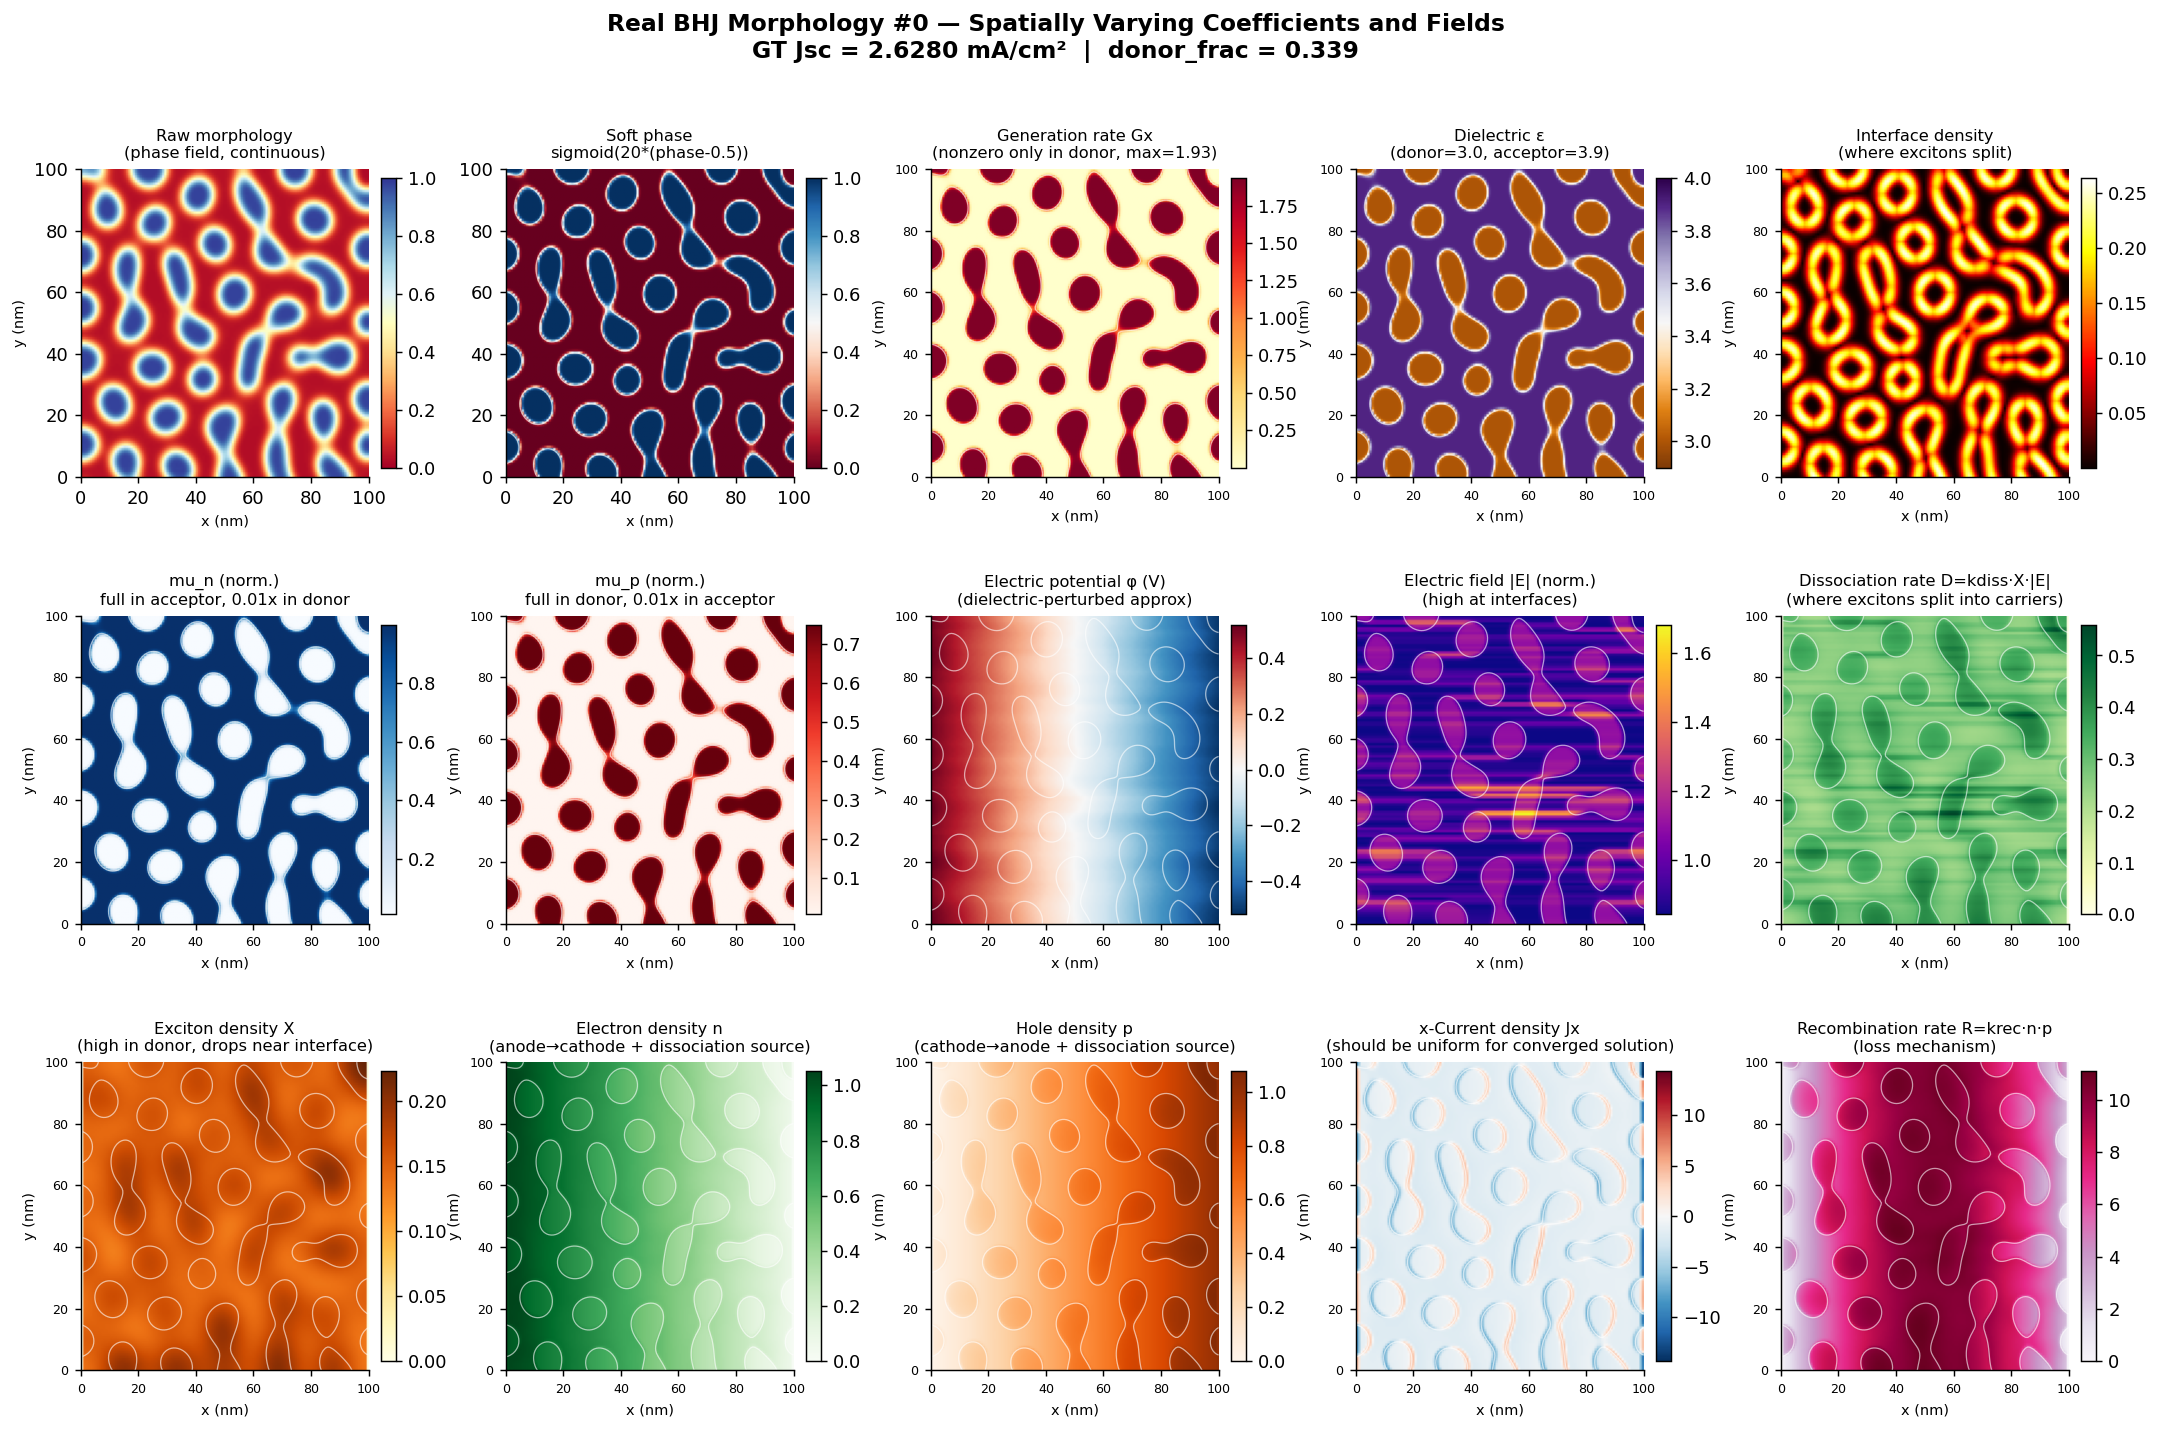

Saved: morphology_0_coefficient_maps.png


In [7]:
ext = [0, 100, 0, 100]   # physical units: nm

fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(3, 5, hspace=0.45, wspace=0.35)
fig.suptitle(
    f'Real BHJ Morphology #{MORPH_IDX} — Spatially Varying Coefficients and Fields\n'
    f'GT Jsc = {gt_jsc:.4f} mA/cm²  |  donor_frac = {(morph_grid>0.5).mean():.3f}',
    fontsize=13, fontweight='bold'
)

def add_morph_contour(ax):
    ax.contour(
        np.linspace(0, 100, G), np.linspace(0, 100, G),
        phase_2d.T, levels=[0.5],
        colors='white', linewidths=0.7, alpha=0.6
    )

def hmap(ax, data, title, cmap, vmin=None, vmax=None, contour=True):
    im = ax.imshow(data.T, origin='lower', cmap=cmap,
                   extent=ext, aspect='auto', vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if contour:
        add_morph_contour(ax)
    ax.set_title(title, fontsize=9, fontweight='500')
    ax.set_xlabel('x (nm)', fontsize=8)
    ax.set_ylabel('y (nm)', fontsize=8)
    ax.tick_params(labelsize=7)

# ── Row 1: Morphology structure ───────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(morph_grid.T, origin='lower', cmap='RdYlBu',
               extent=ext, aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Raw morphology\n(phase field, continuous)', fontsize=9)
ax.set_xlabel('x (nm)', fontsize=8); ax.set_ylabel('y (nm)', fontsize=8)

ax = fig.add_subplot(gs[0, 1])
im = ax.imshow(soft_2d.T, origin='lower', cmap='RdBu',
               extent=ext, aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
add_morph_contour(ax)
ax.set_title('Soft phase\nsigmoid(20*(phase-0.5))', fontsize=9)
ax.set_xlabel('x (nm)', fontsize=8)

hmap(fig.add_subplot(gs[0, 2]), Gx_2d,
     f'Generation rate Gx\n(nonzero only in donor, max={Gx_nd:.2f})',
     'YlOrRd')

hmap(fig.add_subplot(gs[0, 3]), eps_2d,
     f'Dielectric ε\n(donor={eps_D}, acceptor={eps_A})',
     'PuOr', vmin=eps_D-0.1, vmax=eps_A+0.1)

# Interface map: gradient magnitude of phase
gx_mg = np.abs(np.gradient(phase_2d, axis=0))
gy_mg = np.abs(np.gradient(phase_2d, axis=1))
interface_map = gx_mg + gy_mg
hmap(fig.add_subplot(gs[0, 4]), interface_map,
     'Interface density\n(where excitons split)',
     'hot', contour=False)

# ── Row 2: Mobility maps + electric field ────────────────────────────────────
hmap(fig.add_subplot(gs[1, 0]), mu_n_2d,
     f'mu_n (norm.)\nfull in acceptor, {muRatio}x in donor',
     'Blues')

hmap(fig.add_subplot(gs[1, 1]), mu_p_2d,
     f'mu_p (norm.)\nfull in donor, {muRatio}x in acceptor',
     'Reds')

hmap(fig.add_subplot(gs[1, 2]), phi_approx * V0,
     'Electric potential φ (V)\n(dielectric-perturbed approx)',
     'RdBu_r')

hmap(fig.add_subplot(gs[1, 3]), E_mag_2d,
     'Electric field |E| (norm.)\n(high at interfaces)',
     'plasma')

hmap(fig.add_subplot(gs[1, 4]), D_diss_2d,
     'Dissociation rate D=kdiss·X·|E|\n(where excitons split into carriers)',
     'YlGn')

# ── Row 3: Field solutions ────────────────────────────────────────────────────
hmap(fig.add_subplot(gs[2, 0]), X_approx,
     'Exciton density X\n(high in donor, drops near interface)',
     'YlOrBr')

hmap(fig.add_subplot(gs[2, 1]), n_approx,
     'Electron density n\n(anode→cathode + dissociation source)',
     'Greens')

hmap(fig.add_subplot(gs[2, 2]), p_approx,
     'Hole density p\n(cathode→anode + dissociation source)',
     'Oranges')

vmax_jx = max(abs(Jt_x.min()), abs(Jt_x.max()))
hmap(fig.add_subplot(gs[2, 3]), Jt_x,
     'x-Current density Jx\n(should be uniform for converged solution)',
     'RdBu_r', vmin=-vmax_jx, vmax=vmax_jx)

# Recombination map
R_rec_2d = krec_nd * n_approx * p_approx
hmap(fig.add_subplot(gs[2, 4]), R_rec_2d,
     'Recombination rate R=krec·n·p\n(loss mechanism)',
     'PuRd')

plt.savefig(f'morphology_{MORPH_IDX}_coefficient_maps.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: morphology_{MORPH_IDX}_coefficient_maps.png')

## Cell 7 — Quantitative analysis: how much does morphology matter?

In [8]:
# ── Key metrics ───────────────────────────────────────────────────────────────
donor_frac     = float((morph_grid > 0.5).mean())
interface_dens = float(interface_map.mean())
X_mean_donor   = float(X_approx[soft_2d > 0.5].mean())
X_mean_accept  = float(X_approx[soft_2d < 0.5].mean()) if (soft_2d < 0.5).any() else 0
D_total        = float(D_diss_2d.mean())
R_total        = float(R_rec_2d.mean())
Jx_uniformity  = float(np.std(Jt_x[-1, :]) / (abs(np.mean(Jt_x[-1, :])) + 1e-8))

print('='*55)
print('MORPHOLOGY ANALYSIS SUMMARY')
print('='*55)
print(f'\nMorphology #{MORPH_IDX}  |  GT Jsc = {gt_jsc:.4f} mA/cm²')
print(f'\n--- Structure ---')
print(f'  Donor fraction          : {donor_frac:.3f}')
print(f'  Interface density       : {interface_dens:.4f}  (higher = more interface)')

print(f'\n--- Exciton behaviour ---')
print(f'  Mean X in donor         : {X_mean_donor:.4f}')
print(f'  Mean X in acceptor      : {X_mean_accept:.4f}')
print(f'  X_donor / X_acceptor    : {X_mean_donor/(X_mean_accept+1e-8):.2f}x  (should be > 1)')

print(f'\n--- Coupling rates ---')
print(f'  Mean dissociation D     : {D_total:.4f}  (excitons splitting)')
print(f'  Mean recombination R    : {R_total:.4f}  (carriers recombining)')
print(f'  D/R ratio               : {D_total/(R_total+1e-8):.4f}  (>1 = dissociation wins)')

print(f'\n--- Current ---')
print(f'  Approx Jsc              : {Jsc_approx:.4f} mA/cm²  (analytical only)')
print(f'  GT Jsc                  : {gt_jsc:.4f} mA/cm²')
print(f'  Jx uniformity at cathode: {Jx_uniformity:.4f}  (0 = perfectly uniform)')

print(f'\n--- What determines Jsc for this morphology ---')
print(f'  1. Exciton diffusion length ~ {np.sqrt(Dx*tau_x)*1e9:.1f} nm')
print(f'  2. Interface density     = {interface_dens:.4f}  '
      f'({"high" if interface_dens > 0.1 else "moderate" if interface_dens > 0.05 else "low"} BHJ mixing)')
print(f'  3. Donor fraction        = {donor_frac:.3f}  '
      f'({"more generation" if donor_frac > 0.5 else "less generation"})')
print(f'  4. D/R ratio             = {D_total/(R_total+1e-8):.3f}  '
      f'({"dissociation-dominated" if D_total > R_total else "recombination-dominated"})')

MORPHOLOGY ANALYSIS SUMMARY

Morphology #0  |  GT Jsc = 2.6280 mA/cm²

--- Structure ---
  Donor fraction          : 0.339
  Interface density       : 0.1043  (higher = more interface)

--- Exciton behaviour ---
  Mean X in donor         : 0.1648
  Mean X in acceptor      : 0.1518
  X_donor / X_acceptor    : 1.09x  (should be > 1)

--- Coupling rates ---
  Mean dissociation D     : 0.3011  (excitons splitting)
  Mean recombination R    : 7.5899  (carriers recombining)
  D/R ratio               : 0.0397  (>1 = dissociation wins)

--- Current ---
  Approx Jsc              : 31.2895 mA/cm²  (analytical only)
  GT Jsc                  : 2.6280 mA/cm²
  Jx uniformity at cathode: 1.8857  (0 = perfectly uniform)

--- What determines Jsc for this morphology ---
  1. Exciton diffusion length ~ 10.0 nm
  2. Interface density     = 0.1043  (high BHJ mixing)
  3. Donor fraction        = 0.339  (less generation)
  4. D/R ratio             = 0.040  (recombination-dominated)


## Cell 8 — Compare multiple morphologies side by side

Selected morphologies: [324, 265, 214, 190, 46, 319]
Their GT Jsc values  : [0.163, 0.774, 1.935, 3.16, 3.954, 4.474]


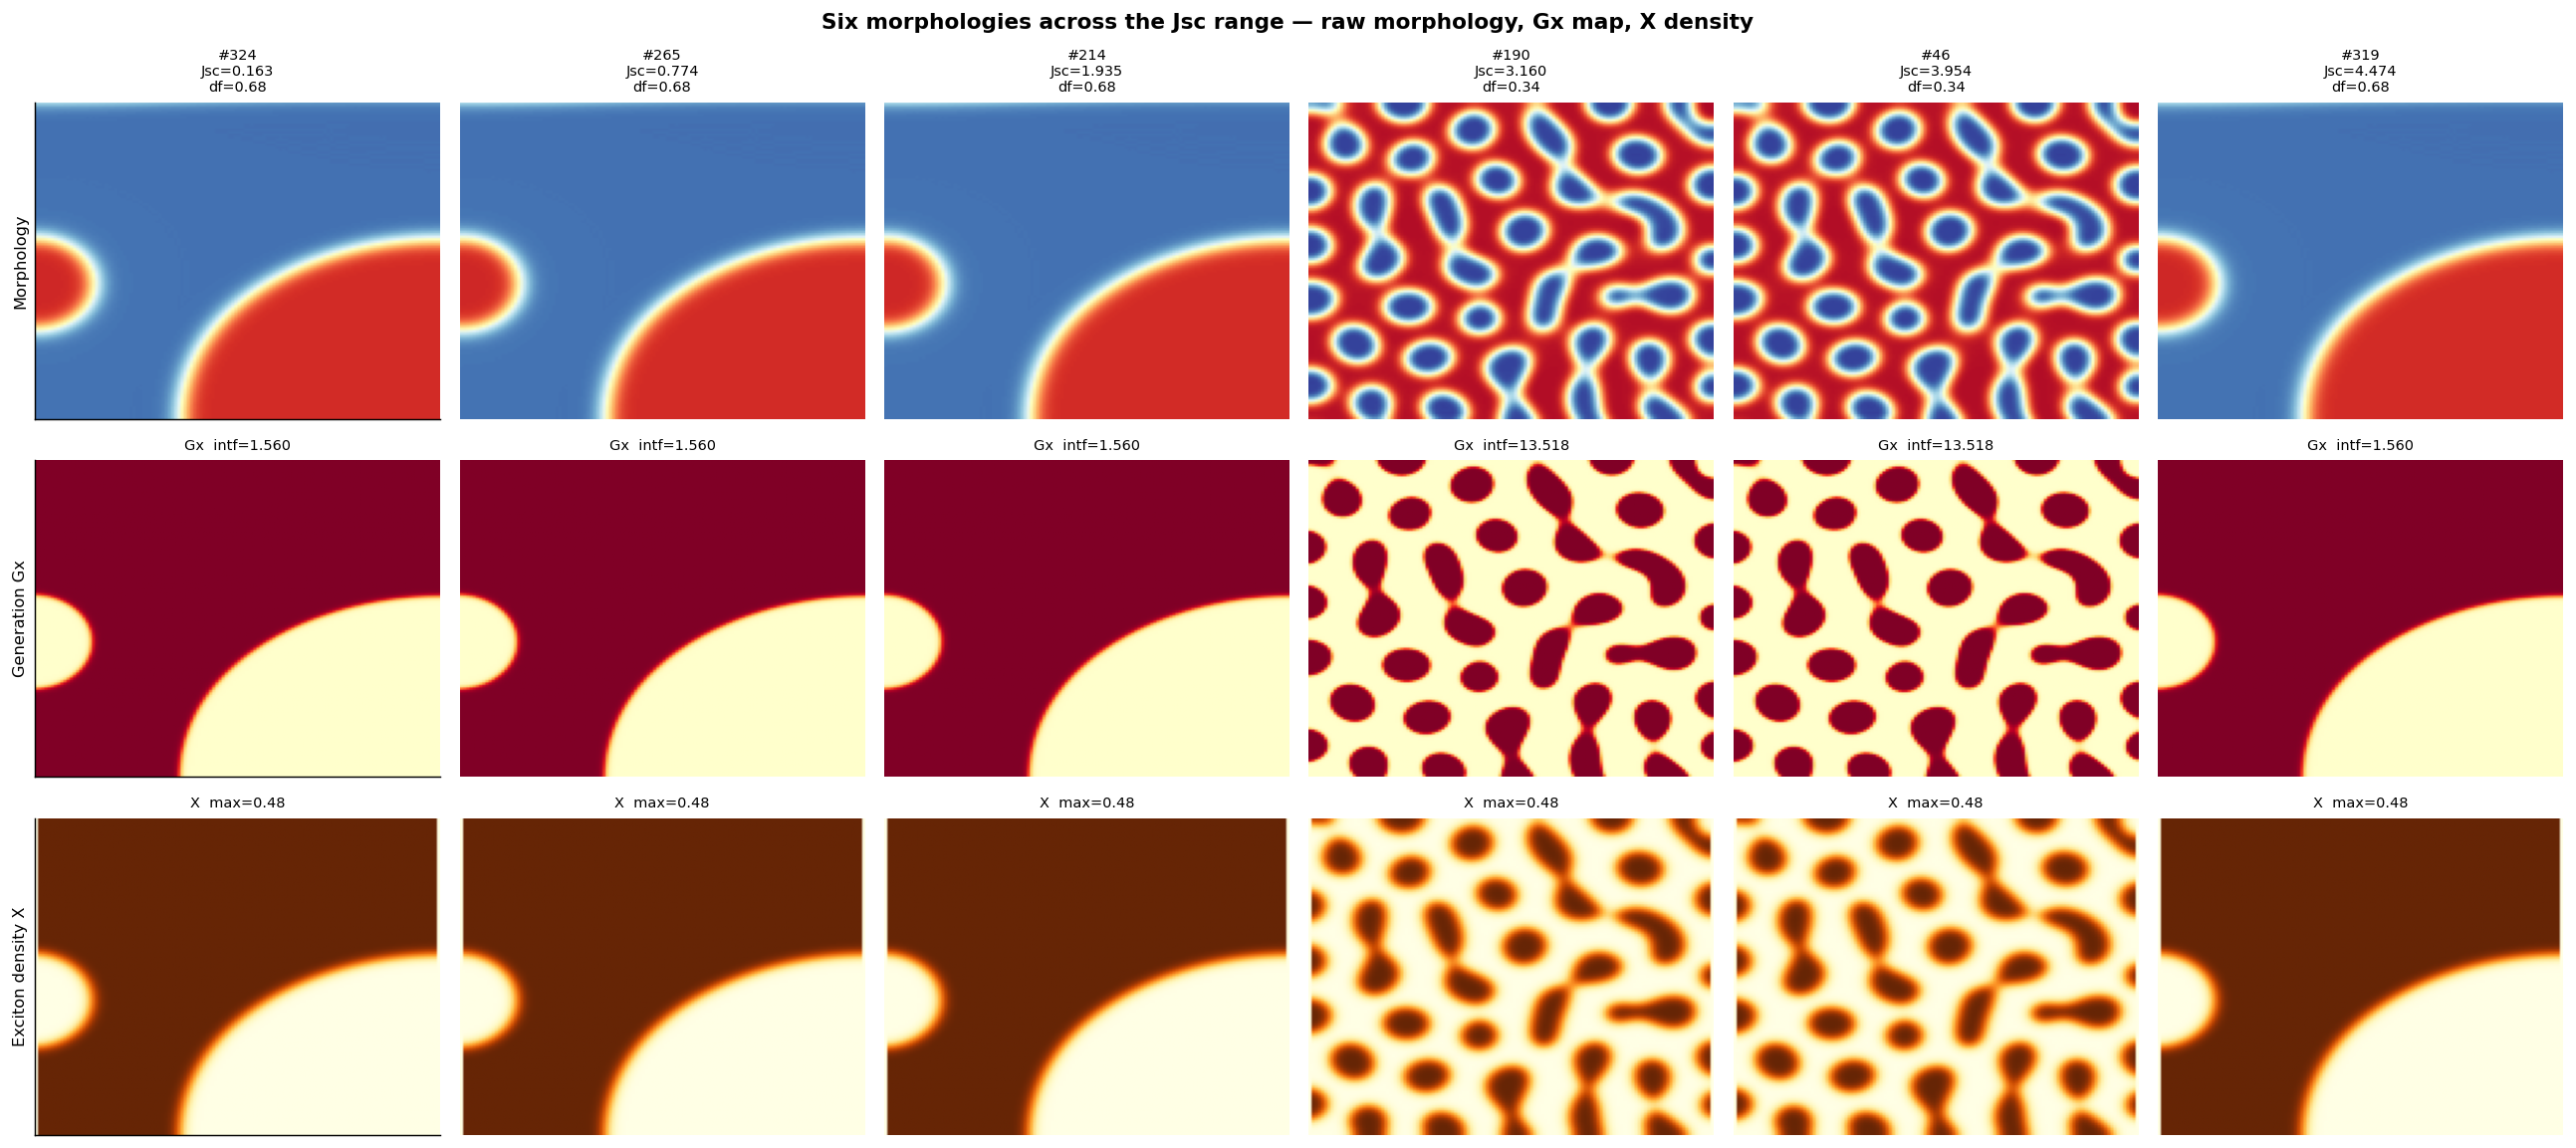

Saved: morphology_comparison_6.png


In [9]:
# Compare 6 morphologies: low, medium, high GT Jsc
# Sample indices spread across Jsc range

# Load a subset to find range
N_SCAN    = min(500, n_total)
jsc_scan  = np.array([float(chem_data[i][2]) for i in range(N_SCAN)])

# Pick 6 spread across Jsc quartiles
pcts      = [5, 20, 40, 60, 80, 95]
thresholds = np.percentile(jsc_scan, pcts)
selected  = [int(np.argmin(np.abs(jsc_scan - t))) for t in thresholds]

print(f'Selected morphologies: {selected}')
print(f'Their GT Jsc values  : {[round(float(chem_data[i][2]),3) for i in selected]}')

fig, axes = plt.subplots(3, 6, figsize=(20, 9))
fig.suptitle('Six morphologies across the Jsc range — raw morphology, Gx map, X density',
             fontsize=12, fontweight='bold')

for col, idx in enumerate(selected):
    mg_i  = np.array(chem_data[idx][0], dtype=np.float32)
    jsc_i = float(chem_data[idx][2])

    # Compute phase and Gx for this morphology
    interp_i = RegularGridInterpolator(
        (np.linspace(0,1,mg_i.shape[0]), np.linspace(0,1,mg_i.shape[1])),
        mg_i, method='linear', bounds_error=False, fill_value=0.5
    )
    ph_i    = interp_i(xy_flat).reshape(G, G)
    soft_i  = 1/(1+np.exp(-20*(ph_i-0.5)))
    Gx_i    = Gx_nd * soft_i

    # X steady state (no-diffusion)
    gx_i, gy_i = np.gradient(ph_i, dx)
    E_i    = np.sqrt((E0*eps_avg/(eps_D*soft_i+eps_A*(1-soft_i)))**2)
    X_i    = Gx_nd * soft_i / (kx_nd + kdiss_nd*E_i + 1e-6)
    X_i    = gaussian_filter(X_i, sigma=2)
    X_i[0,:] = 0; X_i[-1,:] = 0

    donor_f_i  = float((mg_i > 0.5).mean())
    intf_i     = float((np.abs(gx_i)+np.abs(gy_i)).mean())

    # Row 0: morphology
    axes[0,col].imshow(mg_i.T, origin='lower', cmap='RdYlBu',
                       extent=ext, aspect='auto', vmin=0, vmax=1)
    axes[0,col].set_title(f'#{idx}\nJsc={jsc_i:.3f}\ndf={donor_f_i:.2f}',
                          fontsize=8)
    axes[0,col].axis('off')

    # Row 1: Gx map
    axes[1,col].imshow(Gx_i.T, origin='lower', cmap='YlOrRd',
                       extent=ext, aspect='auto', vmin=0, vmax=Gx_nd)
    axes[1,col].set_title(f'Gx  intf={intf_i:.3f}', fontsize=8)
    axes[1,col].axis('off')

    # Row 2: X map
    axes[2,col].imshow(X_i.T, origin='lower', cmap='YlOrBr',
                       extent=ext, aspect='auto')
    axes[2,col].set_title(f'X  max={X_i.max():.2f}', fontsize=8)
    axes[2,col].axis('off')

# Row labels
for row, label in enumerate(['Morphology', 'Generation Gx', 'Exciton density X']):
    axes[row, 0].axis('on')
    axes[row, 0].set_ylabel(label, fontsize=9)
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])

plt.tight_layout()
plt.savefig('morphology_comparison_6.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: morphology_comparison_6.png')

## Cell 9 — Interface length vs GT Jsc scatter

Computing interface density for first 500 morphologies...


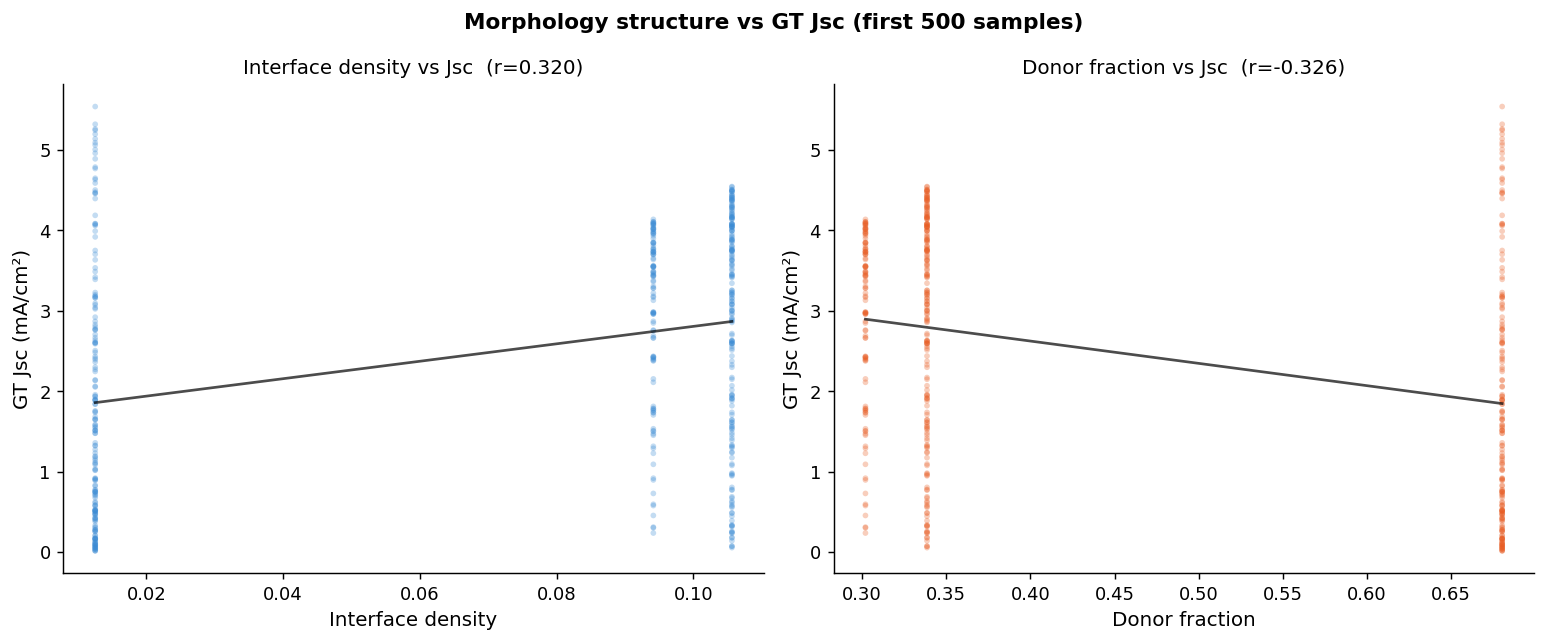

r(interface, Jsc)  = 0.3201
r(donor_frac, Jsc) = -0.3257
(Positive r = more interface/donor = higher Jsc — confirms physics)


In [10]:
# Compute interface density for the first 500 morphologies
# and plot against GT Jsc to confirm the physics

print('Computing interface density for first 500 morphologies...')
intf_list  = []
donor_list = []
jsc_list   = jsc_scan.tolist()

for i in range(N_SCAN):
    mg_i = np.array(chem_data[i][0], dtype=np.float32)
    gx_i = np.abs(np.gradient(mg_i, axis=0))
    gy_i = np.abs(np.gradient(mg_i, axis=1))
    intf_list.append(float((gx_i+gy_i).mean()))
    donor_list.append(float((mg_i > 0.5).mean()))

intf_arr  = np.array(intf_list)
donor_arr = np.array(donor_list)
jsc_arr   = np.array(jsc_list)

from scipy import stats
r_intf,  _ = stats.pearsonr(intf_arr,  jsc_arr)
r_donor, _ = stats.pearsonr(donor_arr, jsc_arr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Morphology structure vs GT Jsc (first 500 samples)',
             fontsize=12, fontweight='bold')

axes[0].scatter(intf_arr, jsc_arr, alpha=0.3, s=10, c='#3B8BD4', edgecolors='none')
m,b = np.polyfit(intf_arr, jsc_arr, 1)
xr = np.linspace(intf_arr.min(), intf_arr.max(), 100)
axes[0].plot(xr, m*xr+b, 'black', lw=1.5, alpha=0.7)
axes[0].set_xlabel('Interface density', fontsize=11)
axes[0].set_ylabel('GT Jsc (mA/cm²)', fontsize=11)
axes[0].set_title(f'Interface density vs Jsc  (r={r_intf:.3f})', fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].scatter(donor_arr, jsc_arr, alpha=0.3, s=10, c='#E85D24', edgecolors='none')
m,b = np.polyfit(donor_arr, jsc_arr, 1)
xr = np.linspace(donor_arr.min(), donor_arr.max(), 100)
axes[1].plot(xr, m*xr+b, 'black', lw=1.5, alpha=0.7)
axes[1].set_xlabel('Donor fraction', fontsize=11)
axes[1].set_ylabel('GT Jsc (mA/cm²)', fontsize=11)
axes[1].set_title(f'Donor fraction vs Jsc  (r={r_donor:.3f})', fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('interface_vs_jsc.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'r(interface, Jsc)  = {r_intf:.4f}')
print(f'r(donor_frac, Jsc) = {r_donor:.4f}')
print('(Positive r = more interface/donor = higher Jsc — confirms physics)')